In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\svenk\OneDrive\Documents\oasis project\Housing.csv");


In [2]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.shape


(545, 13)

In [5]:
df.isna().sum().sort_values(ascending=False)


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
df.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df.select_dtypes(include=['int64', 'float64']).columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [8]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
df.select_dtypes(include=['int64', 'float64']).isna().sum()


price        0
area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
dtype: int64

In [10]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric = df_numeric.fillna(df_numeric.mean())


In [11]:
df_numeric.isna().sum()


price        0
area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
dtype: int64

In [12]:
y = df_numeric['price']


In [13]:
X = df_numeric.drop('price', axis=1)


In [14]:
X.head()


,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2


In [15]:
from sklearn.model_selection import train_test_split


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((436, 5), (109, 5), (436,), (109,))

In [18]:
from sklearn.linear_model import LinearRegression


In [19]:
model = LinearRegression()


In [20]:
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test)


In [22]:
pd.DataFrame({
    'Actual Price': y_test.values[:5],
    'Predicted Price': y_pred[:5]
})


,Actual Price,Predicted Price
0,4060000,6.178628e+06
1,6650000,6.370141e+06
2,3710000,3.283148e+06
3,6440000,4.226008e+06
4,2800000,3.409686e+06


In [23]:
from sklearn.metrics import mean_squared_error, r2_score


In [24]:
mse = mean_squared_error(y_test, y_pred)
mse


2292721545725.3613

In [25]:
r2 = r2_score(y_test, y_pred)
r2


0.5464062355495873

In [26]:
rmse = np.sqrt(mse)
rmse


np.float64(1514173.552049223)

In [27]:
MSE = 2,292,721,545,725.36


In [29]:
RMSE= 1,514,173


In [32]:
r2 = 0.5464


In [34]:
import matplotlib.pyplot as plt


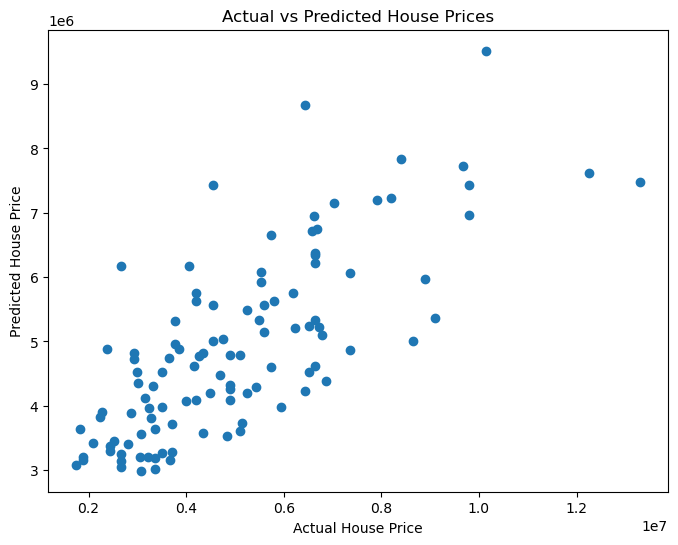

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


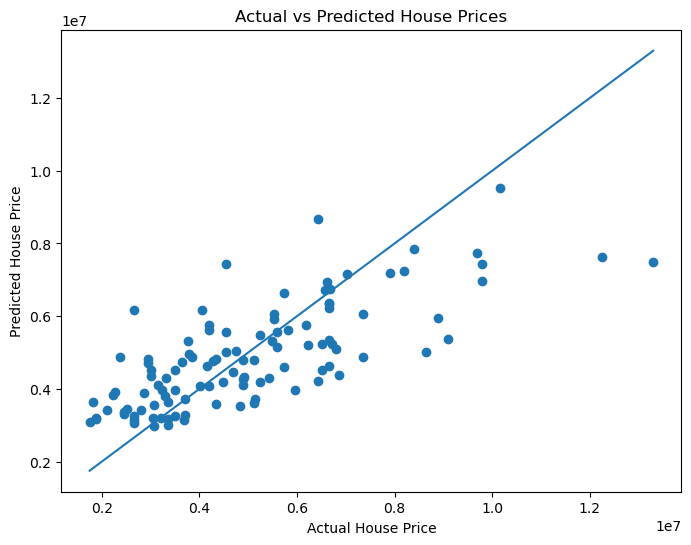

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()
